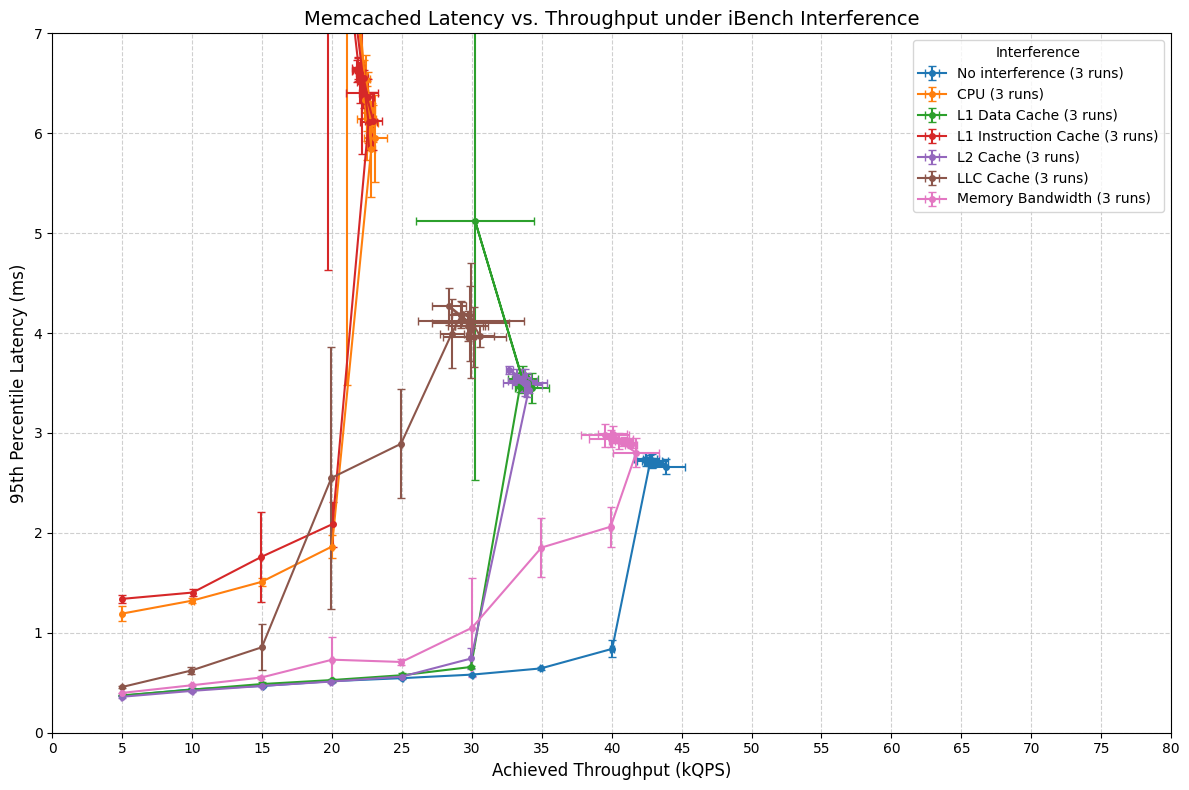

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import glob
import os
import io


def parse_mcperf_file(filepath):
    """parses a single mcperf log and returns a cleaned dataframe."""
    with open(filepath, 'r') as f:
        lines = f.readlines()

    # filter only lines within the data table, including header and 'read' rows
    table_lines = [l for l in lines if l.startswith('#') or l.startswith('read')]
    df = pd.read_csv(io.StringIO("".join(table_lines)), sep=r'\s+')
    # clean up column names (e.g. remove # from #type)
    df.columns = [c.replace('#', '') for c in df.columns]
    # convert p95 from microseconds to milliseconds
    df['p95_ms'] = df['p95'] / 1000.0
    # only feats needed
    return df[['target', 'QPS', 'p95_ms']]


# data aggregation
log_files = glob.glob("../data/part-1/*.log")
interference_types = ['baseline', 'cpu', 'l1d', 'l1i', 'l2', 'llc', 'membw']
all_data = []

for file in log_files:
    # assumption: format `name-HH-MM.log`
    filename = os.path.basename(file)
    config_name = filename.split('-')[0]

    if config_name in interference_types:
        df = parse_mcperf_file(file)
        df['config'] = config_name
        all_data.append(df)

master_df = pd.concat(all_data)


# compute mean and standard deviations for error bars by grouping config and target QPS
stats = master_df.groupby(['config', 'target']).agg({
    'QPS': ['mean', 'std', 'count'],
    'p95_ms': ['mean', 'std']
}).reset_index()
# flatten the multi-index columns
stats.columns = ['config', 'target', 'qps_mean', 'qps_std', 'run_count', 'p95_mean', 'p95_std']


# plotting
plt.figure(figsize=(12, 8))
cmap = mpl.colormaps['tab10']
display_names = {
    'baseline': 'No interference',
    'cpu': 'CPU',
    'l1d': 'L1 Data Cache',
    'l1i': 'L1 Instruction Cache',
    'l2': 'L2 Cache',
    'llc': 'LLC Cache',
    'membw': 'Memory Bandwidth'
}


for i, config in enumerate(interference_types):
    subset = stats[stats['config'] == config].sort_values('target')
    if subset.empty: continue

    # get run counts of interference configs
    num_runs = int(subset['run_count'].iloc[0])
    label_name = f"{display_names.get(config, config)} ({num_runs} runs)"

    plt.errorbar(
        subset['qps_mean'] / 1000,
        subset['p95_mean'],
        xerr=subset['qps_std'] / 1000,
        yerr=subset['p95_std'],
        label=label_name,
        capsize=3, marker='o', markersize=4, linestyle='-', linewidth=1.5,
        color=cmap(i)
    )


# 0-80k Query Per Secure (5k resolution), 0-7 ms
plt.title('Memcached Latency vs. Throughput under iBench Interference', fontsize=14)
plt.xlabel('Achieved Throughput (kQPS)', fontsize=12)
plt.ylabel('95th Percentile Latency (ms)', fontsize=12)
plt.xlim(0, 80)
plt.xticks(np.arange(0, 81, 5))
plt.ylim(0, 7)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.legend(title="Interference", loc='upper right')
plt.tight_layout()
plt.savefig('../reports/figures/part-1-a-latency.png', dpi=300, bbox_inches='tight')
plt.show()